# Inspect the local meme datasets

This notebook displays **one example from Facebook Hateful Memes and one from each dataset in `hf_raw`**, then summarizes storage, splits, labels, and per-image features. It reads the copied datasets in this project's `data` directory and requires no download.

Run all cells from top to bottom. Requirements: `pyarrow`, `pandas`, `Pillow`, and `IPython` (already listed in the project requirements). Examples are deterministic: the first training record of each dataset. Change `SAMPLE_INDEX` below to inspect another record. These examples are a data-loading check, not a representative sample or model evaluation.

In [1]:
from pathlib import Path
from io import BytesIO
from collections import Counter
import json
import pandas as pd
import pyarrow.parquet as pq
from PIL import Image
from IPython.display import display, Markdown

# Works when Jupyter starts in notebooks/, the project, or its parent workspace.
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents, cwd / "meme-understanding"]
PROJECT_ROOT = next((p for p in candidates
                     if (p / "data" / "hf_raw").is_dir()
                     and (p / "data" / "facebook_hateful_memes").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Start Jupyter in meme-understanding or its notebooks folder.")
DATA_ROOT = PROJECT_ROOT / "data"
FB_ROOT = DATA_ROOT / "facebook_hateful_memes" / "data"
HF_ROOT = DATA_ROOT / "hf_raw"
SAMPLE_INDEX = 0
print("Data directory:", DATA_ROOT)

summary_rows = []
feature_rows = []
check_rows = []
hf_schemas = {}

def show_image(image):
    print(f"Decoded image: {image.width} × {image.height}; mode={image.mode}")
    preview = image.copy()
    preview.thumbnail((720, 540))
    display(preview)

def show_fields(record):
    # Never print raw binary image data.
    rows = []
    for name, value in record.items():
        if name == "image" and isinstance(value, dict):
            value = {"bytes": f"{len(value.get('bytes') or b''):,} embedded bytes",
                     "path": value.get("path")}
        rows.append({"feature": name, "value": value})
    with pd.option_context("display.max_colwidth", None):
        display(pd.DataFrame(rows))

Data directory: C:\Users\user\Desktop\Foundational Models for Meme Understanding\meme-understanding\data


## 1. Facebook Hateful Memes

Actual folder name: `facebook_hateful_memes/data/`. Each JSONL line is an annotation; `img` points to a separate PNG relative to this folder. The local README defines `0 = not-hateful` and `1 = hateful`. The test split does not provide a ground-truth label.

### Facebook Hateful Memes — training example

,feature,value
0,id,42953
1,img,img/42953.png
2,label,0
3,text,its their character not their color that matters


Decoded image: 265 × 400; mode=RGB


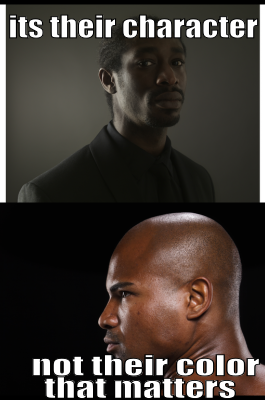

Source annotation: C:\Users\user\Desktop\Foundational Models for Meme Understanding\meme-understanding\data\facebook_hateful_memes\data\train.jsonl
Source image: C:\Users\user\Desktop\Foundational Models for Meme Understanding\meme-understanding\data\facebook_hateful_memes\data\img\42953.png


Image is a compilation of assets, including ©Getty Image.

In [2]:
fb_records = {}
for file in sorted(FB_ROOT.glob("*.jsonl")):
    with file.open(encoding="utf-8") as stream:
        records = [json.loads(line) for line in stream if line.strip()]
    fb_records[file.stem] = records
    fields = sorted({key for record in records for key in record})
    labels = Counter(str(record["label"]) for record in records if "label" in record)
    missing_images = sum(not (FB_ROOT / record["img"]).is_file() for record in records)
    summary_rows.append({"dataset": "Facebook Hateful Memes", "split": file.stem,
                         "records": len(records), "files": 1, "storage": "JSONL + external PNG",
                         "labels (count)": dict(labels),
                         "records without label": sum("label" not in r for r in records)})
    for field in fields:
        feature_rows.append({"dataset": "Facebook Hateful Memes", "split": file.stem,
                             "feature": field,
                             "type": ", ".join(sorted({type(r[field]).__name__ for r in records if field in r})),
                             "null / absent": sum(r.get(field) is None for r in records)})
    check_rows.append({"dataset": "Facebook Hateful Memes", "check": f"{file.stem}: image paths exist",
                       "result": missing_images == 0, "detail": f"{missing_images} missing files"})

sample = fb_records["train"][SAMPLE_INDEX]
display(Markdown("### Facebook Hateful Memes — training example"))
show_fields(sample)
with Image.open(FB_ROOT / sample["img"]) as source:
    show_image(source.convert("RGB"))
print("Source annotation:", FB_ROOT / "train.jsonl")
print("Source image:", FB_ROOT / sample["img"])
display(Markdown("Image is a compilation of assets, including ©Getty Image."))

## 2. One image from every `hf_raw` dataset

Each dataset contains split shards such as `train-00000-of-00002.parquet`. All shards belonging to a split form that split. The `.cache` directory is download metadata and is excluded.

`image` is a struct containing `bytes` and `path`. The notebook decodes the embedded bytes directly with Pillow. It reads annotations separately from image bytes to avoid loading several gigabytes of images into memory. Field null counts below refer to top-level fields; they do not measure empty strings or annotation quality.

### Harmful_en__HarMeme — train example

Source shard: hf_raw\Harmful_en__HarMeme\train-00000-of-00001.parquet


,feature,value
0,id,ca330b012071c30702605b41cdb39104
1,image,"{'bytes': '148,064 embedded bytes', 'path': 'memes_44.png'}"
2,text,THIS HIGHLY RATED SHIT-SHOW\nIS THE REASON WHY\nAMERICA IS LOW ON TOILET PAPER\nimgflip.com\nLike a train wreck you just can't\nhelp watching\n
3,label,partially-harmful
4,task_description,"Consider whether the meme's content may cause harm to any individuals or groups. Assign one of these labels: 'not-harmful' for safe memes, 'partially-harmful' for those with questionable aspects, or 'very-harmful' for openly hazardous data."
5,explanation,"The meme uses a formal portrait of a person in a suit and tie, combined with derogatory language in the text, specifically calling them a ""highly rated shit-show."" The phrase ""IS THE REASON WHY AMERICA IS LOW ON TOILET PAPER"" is a metaphorical insult, equating the person to waste and blaming them for a national shortage, which is a form of ridicule. The additional text, ""Like a train wreck you just can't help watching,"" further mocks the individual by suggesting their actions are disastrous yet captivating. These elements together constitute targeted mockery and personal attack, but do not rise to the level of explicit hate speech or incitement, aligning with the rubric for 'partially-harmful' content. The harm is present through personal denigration and crude metaphor, but it is not extreme or violent."
6,native_label,
7,native_task_description,
8,native_explanation,"The meme features a person in a suit and tie, paired with text that labels them a ""highly rated shit-show,"" which is a clear insult. The statement ""IS THE REASON WHY AMERICA IS LOW ON TOILET PAPER"" uses a crude metaphor to blame and demean the individual, implying they are the cause of a negative situation. The line ""Like a train wreck you just can't help watching"" adds further ridicule by comparing the person's actions to a disaster. These visual and textual cues work together to mock and belittle the subject, fitting the 'partially-harmful' label as defined by the rubric. The content is harmful due to its personal attacks and crude language, but it does not reach the threshold of severe or very harmful content."
9,informativeness,None


Decoded image: 500 × 608; mode=RGB


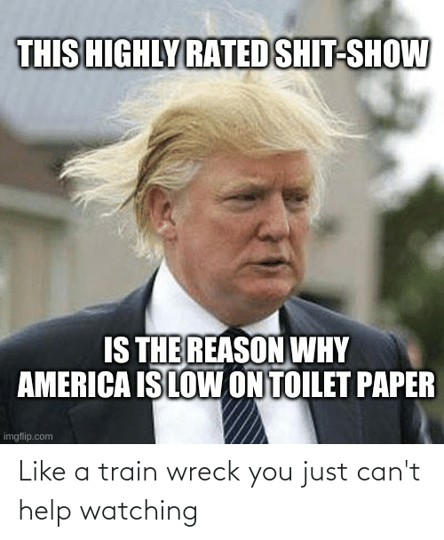

### Hateful_en__MIMIC_Islamophpbia — train example

Source shard: hf_raw\Hateful_en__MIMIC_Islamophpbia\train-00000-of-00001.parquet


,feature,value
0,id,9ee4251f9de322df429aa9c694d38a61
1,image,"{'bytes': '91,038 embedded bytes', 'path': 'lezk1dqzk9671.jpeg'}"
2,text,send a lot of hate to them\ncall them kuffar\nsay you are changing islam for you own desires\nWhy do the progressive hate us?\nmade with mematic
3,label,not-hateful
4,task_description,"What is the nature of the content in this meme regarding Islam? Identify if it contains hateful or prejudiced messages about Muslims. Classify as: 'hateful' for memes with Islamophobic content, and 'not-hateful' for memes without."
5,explanation,"This meme uses a sequence of images showing a person putting on a rainbow clown wig, which is a visual cue often used to mock or satirize someone's behavior. The text progresses from statements like ""I send a lot of hate to them"" and ""I call them kuffar"" to ""I say you are changing islam for you own desires,"" culminating in the rhetorical question ""Why do the progressive hate us?"" The visual transformation into a clown reinforces the idea that the speaker's actions are hypocritical or foolish rather than promoting hostility toward Muslims. The meme critiques a certain attitude within a group, but does not employ anti-Muslim stereotypes or hostile framing against Muslims as a whole. Therefore, according to the rubric, it fits the ""not-hateful"" label because it does not target Muslims with hate or negative stereotypes."
6,native_label,
7,native_task_description,
8,native_explanation,"This meme features a person gradually putting on a rainbow clown wig, a visual element commonly used to highlight irony or ridicule. The accompanying text includes phrases such as ""I send a lot of hate to them"" and ""I call them kuffar,"" followed by ""I say you are changing islam for you own desires"" and ends with ""Why do the progressive hate us?"" The clown imagery suggests the speaker is being mocked for their contradictory or unreasonable behavior, rather than expressing hatred toward Muslims. The meme does not present anti-Muslim stereotypes or direct hostility toward the Muslim community. Based on the rubric, this justifies the ""not-hateful"" label, as the content does not constitute Islamophobic hate or stereotyping."
9,informativeness,None


Decoded image: 1185 × 1401; mode=RGB


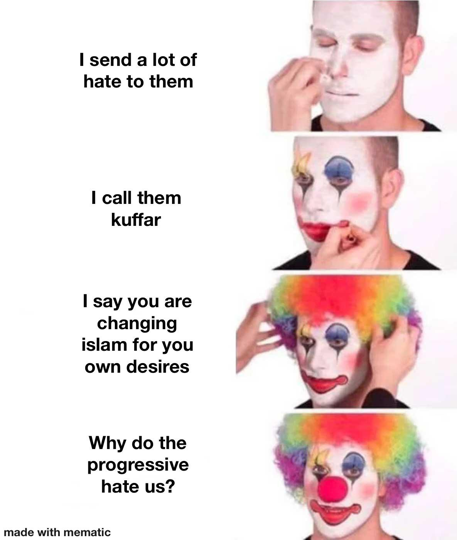

### Hateful_en__MMHS — train example

Source shard: hf_raw\Hateful_en__MMHS\train-00000-of-00005.parquet


,feature,value
0,id,48bae25a89bf2f3b6a45f4c3f3c9e797
1,image,"{'bytes': '77,863 embedded bytes', 'path': '1056047073148182529.jpg'}"
2,text,"12:55 AM hotnewhiphop.com hnhh NEWS TOP100 SONGS STORE View More on Instagram ㄇ 2,090,154 likes 6ix9ine GOD IS GOOD GOD IS... GOOD! view all 30,284 comments : Financial Aid College Search Free SAT Prep Let us help SAT"
3,label,hateful
4,task_description,"What is the classification of this meme? Scrutinize the content for any signs of hate speech, prejudice, or discrimination. Classify as: 'hateful' if any of these elements are detected, and 'not-hateful' if the meme is free from them."
5,explanation,"This meme is labeled as hateful due to the combination of visual and textual cues that target a specific group. Visually, the image shows a person in a suit standing on a city sidewalk, which is a common stereotype used to mock certain ethnic or religious groups, particularly when paired with the context of financial aid and SAT prep advertisements. The textual element, especially the phrase 'GOD IS GOOD GOD IS... GOOD!' and the prominent display of 'Financial Aid College Search Free SAT Prep,' can be interpreted as a coded reference to stereotypes about certain groups (such as South Asians or immigrants) being overly focused on academic achievement and financial assistance. The juxtaposition of the suited figure and the SAT ad reinforces this stereotype, aligning with the rubric's requirement to identify targeted groups and hate cues. The meme uses these elements together to perpetuate a negative stereotype, which justifies the 'hateful' label."
6,native_label,
7,native_task_description,
8,native_explanation,"This meme is considered hateful because it uses both visual and textual elements to target and stereotype a particular group. The image of a person in a suit on a city street, combined with the visible 'Financial Aid College Search Free SAT Prep' banner, plays into common negative stereotypes about certain ethnic or immigrant groups being obsessed with academic success and financial aid. The text 'GOD IS GOOD GOD IS... GOOD!' may further allude to religious or cultural backgrounds, amplifying the stereotype. The interaction between the suited figure and the SAT advertisement is not coincidental; it is meant to mock or belittle the targeted group, which fits the rubric's definition of hate cues and targeted group identification. This combination of cues supports the assignment of the 'hateful' label."
9,informativeness,None


Decoded image: 500 × 888; mode=RGB


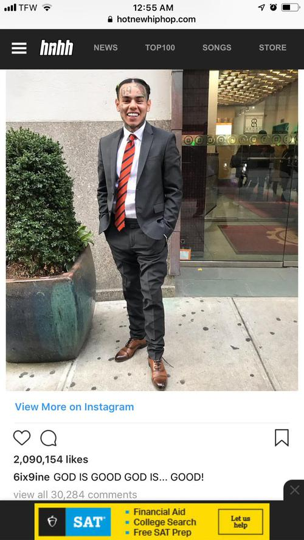

### humour_en__memotion — train example

Source shard: hf_raw\humour_en__memotion\train-00000-of-00002.parquet


,feature,value
0,id,00ee2e4e47bdae689bb23ac782975bb8
1,image,"{'bytes': '44,681 embedded bytes', 'path': 'image_4459.jpg'}"
2,text,I think... I love you. Oh. Thank you. It's no problem.
3,label,not-funny
4,task_description,"Please assess the comedic quality of the meme. The classification should reflect its position on a scale from not humorous to extremely humorous. Classify as: 'not-funny', 'funny', 'very-funny', or 'hilarious'."
5,explanation,"This meme consists of four panels showing a conversation between two people. Visually, the first panel shows one person confessing with the text ""I think... I love you."" The second panel shows them hugging, accompanied by the underwhelming response ""Oh."" In the third panel, the reply ""Thank you."" is given, and the final panel shows the first person awkwardly responding with ""It's no problem."" The humor is meant to arise from the mismatch between the emotional confession and the flat, indifferent responses. However, the delivery is very subdued, and the punchline lacks any strong comedic twist or exaggeration. The visual cues of a mundane setting and the characters' neutral body language reinforce the lack of overt humor, justifying the 'not-funny' label as there is little to no comedic impact."
6,native_label,
7,native_task_description,
8,native_explanation,"This meme uses a four-panel format to depict an emotionally charged moment that falls flat. The first visual cue is the serious expression and posture during the confession, ""I think... I love you."" The second cue is the awkward hug and the lackluster response, ""Oh."" Textually, the sequence continues with ""Thank you."" and ""It's no problem,"" which are unexpectedly unemotional replies to a love confession. The intended joke is the anticlimactic and awkward exchange, but the absence of exaggeration or clever wordplay makes the meme feel more uncomfortable than funny. The image and text together create a scene that is awkward rather than humorous, aligning with the 'not-funny' label."
9,informativeness,None


Decoded image: 700 × 523; mode=RGB


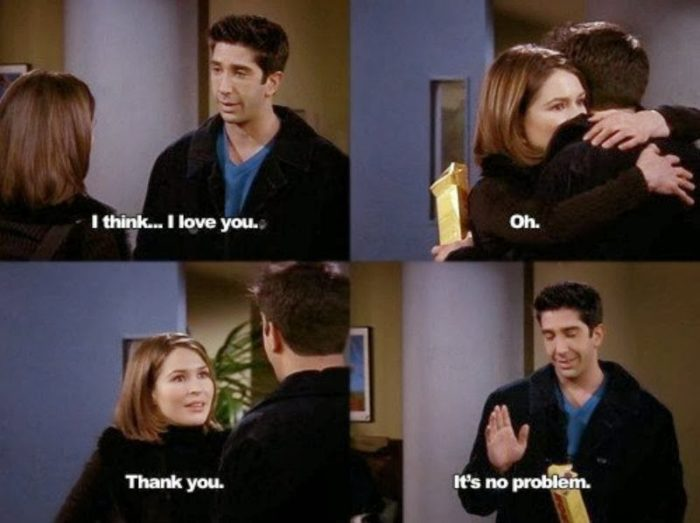

### misogynous_en__MAMI — train example

Source shard: hf_raw\misogynous_en__MAMI\train-00000-of-00004.parquet


,feature,value
0,id,fef96843e9016aa9625f2cd9c865550e
1,image,"{'bytes': '162,885 embedded bytes', 'path': '8716.jpg'}"
2,text,GETS MARRIED TO GIRL OF HIS DREAMS SHE DOESN'T GIVE HEAD mame game.net
3,label,misogynous
4,task_description,"Classify whether the meme contains misogynous content. Identify if it exhibits prejudice, discrimination, objectification, or hatred towards women. Classify as: 'misogynous' if such content is present, or 'not-misogynous' if it is not."
5,explanation,"This meme is labeled misogynistic because it expresses sexist hostility by reducing a woman’s value in marriage to her willingness to perform a specific sexual act. The text ""GETS MARRIED TO GIRL OF HIS DREAMS SHE DOESN'T GIVE HEAD"" implies disappointment and objectifies the woman, suggesting her worth is tied to sexual compliance. The image features a man, reinforcing the male perspective and expectation. The meme’s structure, with bold white text over a photo, is typical of memes that mock or criticize others. By framing the woman’s refusal as a punchline, the meme perpetuates harmful gender stereotypes and aligns with the rubric’s definition of misogynistic content."
6,native_label,
7,native_task_description,
8,native_explanation,"This meme is labeled misogynistic because it expresses sexist hostility by reducing a woman’s value in marriage to her willingness to perform a specific sexual act. The text ""GETS MARRIED TO GIRL OF HIS DREAMS SHE DOESN'T GIVE HEAD"" implies disappointment and objectifies the woman, suggesting her worth is tied to sexual compliance. The image features a man, reinforcing the male perspective and expectation. The meme’s structure, with bold white text over a photo, is typical of memes that mock or criticize others. By framing the woman’s refusal as a punchline, the meme perpetuates harmful gender stereotypes and aligns with the rubric’s definition of misogynistic content."
9,informativeness,None


Decoded image: 640 × 640; mode=RGB


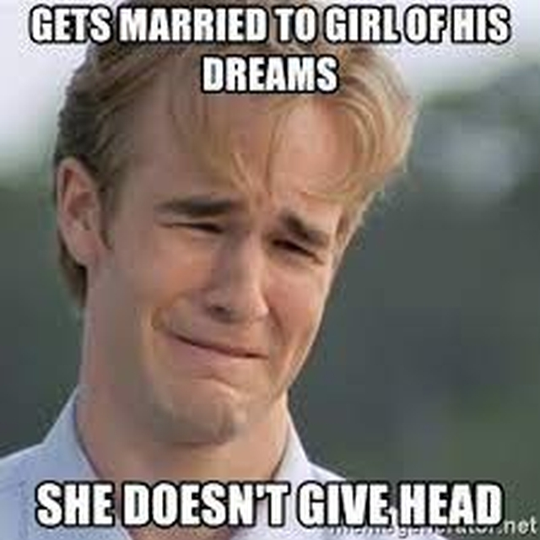

### offensive_en__memotion — train example

Source shard: hf_raw\offensive_en__memotion\train-00000-of-00002.parquet


,feature,value
0,id,24a79ef8831c44026ae1cf381f3f5eac
1,image,"{'bytes': '59,703 embedded bytes', 'path': 'image_31.jpg'}"
2,text,OH THERE'S A NEW AVENGERS MOVIE? TELL ME AGAIN HOW MUCH YOU ARE GOING TO AVOID SPOILERS
3,label,slightly-offensive
4,task_description,"Review the meme and assess whether it is offensive or not. Indicate its offensiveness by selecting: 'not-offensive', 'slightly-offensive', 'very-offensive', or 'hateful-offensive'."
5,explanation,"The meme uses the well-known image of a character in a purple jacket and top hat, who is often associated with a sarcastic or condescending tone. The text, ""OH THERE'S A NEW AVENGERS MOVIE? TELL ME AGAIN HOW MUCH YOU ARE GOING TO AVOID SPOILERS,"" employs sarcasm to mock people who are overly concerned about avoiding spoilers. The visual cue of the character's exaggerated pose and expression reinforces the mocking attitude conveyed in the text. This combination creates a tone that is dismissive and slightly belittling toward a group of people, but it does not cross into harsh insult or hate. According to the rubric, this fits the 'slightly-offensive' label because it uses mild sarcasm to poke fun at a specific behavior without being overtly aggressive or hateful."
6,native_label,
7,native_task_description,
8,native_explanation,"The meme features a recognizable character in a purple jacket and top hat, known for a sarcastic demeanor, which visually signals a mocking intent. The text, ""OH THERE'S A NEW AVENGERS MOVIE? TELL ME AGAIN HOW MUCH YOU ARE GOING TO AVOID SPOILERS,"" uses sarcasm to ridicule those who are vocal about avoiding movie spoilers. The character's body language and attire amplify the condescending tone of the message. The interaction between the sarcastic image and the dismissive text targets a specific group in a mildly offensive way. This aligns with the 'slightly-offensive' label, as the meme teases without resorting to strong insults or hate."
9,informativeness,None


Decoded image: 401 × 400; mode=RGB


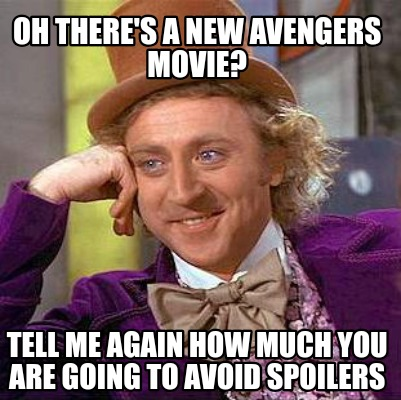

### sarcasm_en__memotion — train example

Source shard: hf_raw\sarcasm_en__memotion\train-00000-of-00002.parquet


,feature,value
0,id,7da38b4329ea91a84d857313cb54407f
1,image,"{'bytes': '13,584 embedded bytes', 'path': 'image_2503.jpg'}"
2,text,I hate how chocolates immediately melt on my fingers. I mean am I THAT HOT?
3,label,general-sarcasm
4,task_description,"Interpret the meme and determine the most accurate sarcasm classification. Reflect on the use and intensity of irony or mockery. Label as: 'not-sarcastic' when the content is honest, 'general-sarcasm' for standard ironic expressions, 'twisted-meaning' for highly manipulated meanings, or 'very-twisted' for particularly intricate sarcasm."
5,explanation,"This meme is labeled as general-sarcasm because it uses irony in its text and visual presentation. The text says, ""I hate how chocolates immediately melt on my fingers. I mean, am I THAT HOT?"" which sarcastically implies that the reason for chocolate melting is the person's own attractiveness or body heat, rather than the obvious scientific explanation. The visual element of a cartoon character with a bemused or exaggerated expression reinforces the playful and ironic tone of the statement. The contradiction between the literal meaning and the intended humorous exaggeration aligns with the definition of general-sarcasm, where irony is present but not extremely twisted. The combination of the silly character and the self-deprecating humor in the text makes the sarcasm clear without being overly complex."
6,native_label,
7,native_task_description,
8,native_explanation,"This meme is labeled as general-sarcasm because it uses irony in its text and visual presentation. The text says, ""I hate how chocolates immediately melt on my fingers. I mean, am I THAT HOT?"" which sarcastically implies that the reason for chocolate melting is the person's own attractiveness or body heat, rather than the obvious scientific explanation. The visual element of a cartoon character with a bemused or exaggerated expression reinforces the playful and ironic tone of the statement. The contradiction between the literal meaning and the intended humorous exaggeration aligns with the definition of general-sarcasm, where irony is present but not extremely twisted. The combination of the silly character and the self-deprecating humor in the text makes the sarcasm clear without being overly complex."
9,informativeness,None


Decoded image: 236 × 246; mode=RGB


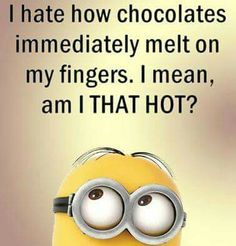

In [3]:
def read_example(files, index):
    if index < 0:
        raise ValueError("SAMPLE_INDEX must be nonnegative")
    remaining = index
    for file in files:
        parquet = pq.ParquetFile(file)
        if remaining >= parquet.metadata.num_rows:
            remaining -= parquet.metadata.num_rows
            continue
        for batch in parquet.iter_batches(batch_size=32):
            if remaining < len(batch):
                return batch.slice(remaining, 1).to_pylist()[0], file
            remaining -= len(batch)
    raise IndexError(f"Sample index {index} exceeds the split size")

dataset_dirs = sorted(p for p in HF_ROOT.iterdir() if p.is_dir() and not p.name.startswith("."))
if not dataset_dirs:
    raise FileNotFoundError(f"No datasets found in {HF_ROOT}")

for folder in dataset_dirs:
    files = sorted(folder.glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No Parquet shards found in {folder}")
    schema = pq.ParquetFile(files[0]).schema_arrow
    hf_schemas[folder.name] = schema
    by_split = {}
    for file in files:
        by_split.setdefault(file.name.split("-", 1)[0], []).append(file)
    for split, split_files in sorted(by_split.items()):
        row_count = 0
        labels = Counter()
        nulls = Counter()
        for file in split_files:
            parquet = pq.ParquetFile(file)
            if not schema.equals(parquet.schema_arrow, check_metadata=False):
                raise ValueError(f"Inconsistent schema: {file}")
            row_count += parquet.metadata.num_rows
            columns = [name for name in schema.names if name != "image"]
            for batch in parquet.iter_batches(batch_size=4096, columns=columns):
                for name in columns:
                    nulls[name] += batch.column(batch.schema.get_field_index(name)).null_count
                labels.update(str(v) for v in batch.column(batch.schema.get_field_index("label")).to_pylist() if v is not None)
        summary_rows.append({"dataset": folder.name, "split": split, "records": row_count,
                             "files": len(split_files), "storage": "Parquet; embedded images",
                             "labels (count)": dict(labels), "records without label": nulls["label"]})
        for field in schema:
            feature_rows.append({"dataset": folder.name, "split": split, "feature": field.name,
                                 "type": str(field.type),
                                 "null / absent": nulls[field.name] if field.name != "image" else "not scanned"})
    chosen_split = "train" if "train" in by_split else sorted(by_split)[0]
    sample, sample_file = read_example(by_split[chosen_split], SAMPLE_INDEX)
    display(Markdown(f"### {folder.name} — {chosen_split} example"))
    print("Source shard:", sample_file.relative_to(DATA_ROOT))
    show_fields(sample)
    payload = sample["image"].get("bytes")
    if not payload:
        raise ValueError(f"Selected example has no embedded image bytes: {sample_file}")
    with Image.open(BytesIO(payload)) as source:
        show_image(source.convert("RGB"))
    check_rows.append({"dataset": folder.name, "check": "Selected image decodes",
                       "result": True, "detail": f"{len(payload):,} embedded bytes"})

## 3. Summary of the local data

The following tables are calculated from the local files: split sizes, shard counts, observed labels, and features for each dataset. Label counts describe stored values; label meanings should be interpreted using each dataset's task description.

In [4]:
summary = pd.DataFrame(summary_rows)
features = pd.DataFrame(feature_rows)
checks = pd.DataFrame(check_rows)
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(summary)
    display(Markdown("### Total records per dataset"))
    display(summary.groupby("dataset", sort=False)["records"].sum().rename("records").to_frame())
    display(Markdown("### Features and their stored types"))
    display(features[["dataset", "feature", "type"]].drop_duplicates().reset_index(drop=True))
    display(Markdown("### Null or absent annotations by split"))
    display(features[features["null / absent"].apply(lambda value: isinstance(value, int) and value > 0)])
    display(Markdown("### Loading checks"))
    display(checks)
assert checks["result"].all(), "One or more loading checks failed"
print(f"Displayed {1 + len(dataset_dirs)} images successfully.")
print("All hf_raw datasets share the same schema:",
      all(next(iter(hf_schemas.values())).equals(schema, check_metadata=False)
          for schema in hf_schemas.values()))

,dataset,split,records,files,storage,labels (count),records without label
0,Facebook Hateful Memes,dev,500,1,JSONL + external PNG,"{'1': 250, '0': 250}",0
1,Facebook Hateful Memes,test,1000,1,JSONL + external PNG,{},1000
2,Facebook Hateful Memes,train,8500,1,JSONL + external PNG,"{'0': 5450, '1': 3050}",0
3,Harmful_en__HarMeme,test,355,1,Parquet; embedded images,"{'partially-harmful': 159, 'not-harmful': 184, 'very-harmful': 12}",0
4,Harmful_en__HarMeme,train,2937,1,Parquet; embedded images,"{'partially-harmful': 1365, 'not-harmful': 1450, 'very-harmful': 122}",0
5,Harmful_en__HarMeme,validation,176,1,Parquet; embedded images,"{'partially-harmful': 80, 'not-harmful': 88, 'very-harmful': 8}",0
6,Hateful_en__MIMIC_Islamophpbia,test,150,1,Parquet; embedded images,"{'not-hateful': 77, 'hateful': 73}",0
7,Hateful_en__MIMIC_Islamophpbia,train,515,1,Parquet; embedded images,"{'not-hateful': 276, 'hateful': 239}",0
8,Hateful_en__MIMIC_Islamophpbia,validation,75,1,Parquet; embedded images,"{'hateful': 38, 'not-hateful': 37}",0
9,Hateful_en__MMHS,test,11881,2,Parquet; embedded images,"{'hateful': 7495, 'not-hateful': 4386}",0


### Total records per dataset

,records
dataset,
Facebook Hateful Memes,10000
Harmful_en__HarMeme,3468
Hateful_en__MIMIC_Islamophpbia,740
Hateful_en__MMHS,59252
humour_en__memotion,6987
misogynous_en__MAMI,11000
offensive_en__memotion,6987
sarcasm_en__memotion,6987


### Features and their stored types

,dataset,feature,type
0,Facebook Hateful Memes,id,int
1,Facebook Hateful Memes,img,str
2,Facebook Hateful Memes,label,int
3,Facebook Hateful Memes,text,str
4,Harmful_en__HarMeme,id,string
5,Harmful_en__HarMeme,image,"struct<bytes: binary, path: string>"
6,Harmful_en__HarMeme,text,string
7,Harmful_en__HarMeme,label,string
8,Harmful_en__HarMeme,task_description,string
9,Harmful_en__HarMeme,explanation,string


### Null or absent annotations by split

,dataset,split,feature,type,null / absent
34,Harmful_en__HarMeme,train,informativeness,float,2937
35,Harmful_en__HarMeme,train,clarity,float,2937
36,Harmful_en__HarMeme,train,plausibility,float,2937
37,Harmful_en__HarMeme,train,faithfulness,float,2937
48,Harmful_en__HarMeme,validation,informativeness,float,176
49,Harmful_en__HarMeme,validation,clarity,float,176
50,Harmful_en__HarMeme,validation,plausibility,float,176
51,Harmful_en__HarMeme,validation,faithfulness,float,176
76,Hateful_en__MIMIC_Islamophpbia,train,informativeness,float,515
77,Hateful_en__MIMIC_Islamophpbia,train,clarity,float,515


### Loading checks

,dataset,check,result,detail
0,Facebook Hateful Memes,dev: image paths exist,True,0 missing files
1,Facebook Hateful Memes,test: image paths exist,True,0 missing files
2,Facebook Hateful Memes,train: image paths exist,True,0 missing files
3,Harmful_en__HarMeme,Selected image decodes,True,"148,064 embedded bytes"
4,Hateful_en__MIMIC_Islamophpbia,Selected image decodes,True,"91,038 embedded bytes"
5,Hateful_en__MMHS,Selected image decodes,True,"77,863 embedded bytes"
6,humour_en__memotion,Selected image decodes,True,"44,681 embedded bytes"
7,misogynous_en__MAMI,Selected image decodes,True,"162,885 embedded bytes"
8,offensive_en__memotion,Selected image decodes,True,"59,703 embedded bytes"
9,sarcasm_en__memotion,Selected image decodes,True,"13,584 embedded bytes"


Displayed 8 images successfully.
All hf_raw datasets share the same schema: True


## 4. How storage and per-image features differ

| Property | Facebook Hateful Memes | Each dataset under `hf_raw` |
|---|---|---|
| Annotation storage | One JSON object per line in `train.jsonl`, `dev.jsonl`, `test.jsonl` | Rows in split-specific Parquet shards |
| Image storage | Separate PNG files under `img/` | Encoded image bytes embedded in the `image` struct |
| Image loading | Open `data/facebook_hateful_memes/data/` + `img` | Decode `image["bytes"]` using `BytesIO` and Pillow |
| Splits | `train`, `dev`, `test` | `train`, `validation`, `test` in the local folders |
| Portability | Copy JSONL files **and** `img/`, preserving relative paths | Copy every required Parquet shard; `.cache` is unnecessary for reading |
| Supervision | Integer labels on train/dev; test labels absent | String labels plus task descriptions and additional annotation fields |

### Facebook: features associated with each image

- **`id`**: integer example identifier.
- **`img`**: relative PNG path, for example `img/42953.png`.
- **`text`**: text associated with the meme.
- **`label`**: `0` (not-hateful) or `1` (hateful); absent from the local test split.

### `hf_raw`: shared features associated with each image

| Feature | Stored type | Description |
|---|---|---|
| `id` | string | Example identifier |
| `image` | struct (`bytes`: binary, `path`: string) | Encoded image and optional path metadata; bytes are used for display |
| `text` | string | Meme text |
| `label` | string | Label for this dataset's task; see observed values above |
| `task_description` | string | Description of the classification task |
| `explanation` | string | Stored explanation associated with the example |
| `native_label` | string | Additional label field in the source schema |
| `native_task_description` | string | Additional source/native task-description field |
| `native_explanation` | string | Additional source/native explanation field |
| `informativeness` | float32 | Stored explanation-evaluation score |
| `clarity` | float32 | Stored explanation-evaluation score |
| `plausibility` | float32 | Stored explanation-evaluation score |
| `faithfulness` | float32 | Stored explanation-evaluation score |
| `llm_judge` | string | Stored judge-related annotation |

The exact score scales and provenance of the `native_*` and judge fields are not established by the storage schema alone. Inspect the displayed values and dataset documentation before using them as training targets. Null counts above help identify unavailable annotations.

The seven local task folders cover **harmfulness** (HarMeme), **Islamophobia** (MIMIC), **hatefulness** (MMHS), **humour**, **offensiveness**, **sarcasm** (Memotion), and **misogyny** (MAMI). Their common schema does **not** imply interchangeable label sets. The Memotion task folders may contain overlapping memes; do not assume all rows across folders are unique images.

This notebook verifies annotation readability, schema consistency within each Parquet dataset, all Facebook image paths, and decoding of the eight displayed examples. It does not decode every image or evaluate annotation correctness.